[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/MonteCarloTodasLasVisitas.ipynb)

# **Monte Carlo con Políticas epsilon-soft**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
!pip install matplotlib tqdm
#!pip install gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

In [3]:
import os
import gc
import torch
import numpy as np
import gymnasium as gym
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad
# Fijar la semilla en Gymnasium

def make_env(env_name):
    env = gym.make(env_name)
    env.reset(seed=seed) # Establece la semilla en el entorno de Gymnasium
    return env
# Ejemplo de creación de un entorno con semilla
name = 'FrozenLake-v1' # Cambiar según el entorno deseado
env = make_env(name)

Usando dispositivo: cpu


In [4]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-greedy**: De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido", eligiendo siempre la acción que maximiza el valor Q estimado por la red neuronal.

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de Deep Q-Learning utilizando una red neuronal para aproximar la función de valor acción Q(s,a).
  - La red neuronal recibe como entrada el estado (codificado mediante embedding) y produce un valor Q para cada acción posible.
  - Se utiliza un buffer de replay (memoria de repetición de experiencias) para almacenar transiciones (estado, acción, recompensa, próximo estado, terminado) y romper las correlaciones temporales.
  - El aprendizaje se realiza mediante muestreo aleatorio de lotes del buffer de replay y actualización de los pesos de la red neuronal mediante descenso de gradiente para minimizar el error cuadrático medio entre los valores Q predichos y los objetivos calculados usando la ecuación de Bellman.
  - El objetivo (target) se calcula como: Qₜₐᵣ₉ₑₜ = R + γ × maxₐ' Q(s', a') donde γ es el factor de descuento.

#### **Código de las políticas y algoritmo MC**
----------------

In [ ]:
# @title Estructuras y Políticas para DQN

# Red Neuronal para aproximar Q(s, a). 
# Usamos Embedding porque FrozenLake tiene estados discretos (0 a 15 o 0 a 63).
class DQN_Network(nn.Module):
    def __init__(self, num_actions, input_dim):
        super(DQN_Network, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, num_actions)
        )

    def forward(self, x):
        return self.net(x)

# Política epsilon-greedy adaptada para DQN
def epsilon_greedy_policy_dqn(q_network, epsilon, state, nA):
    if random.random() < epsilon:
        return random.randint(0, nA - 1)
    else:
        state_t = torch.tensor([state], dtype=torch.long)
        with torch.no_grad():
            q_values = q_network(state_t)
        return torch.argmax(q_values).item()

# Política Greedy final a partir de la Red Neuronal Q (Sustituye a la anterior)
def pi_star_from_Q(env, q_network):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset()
    actions = ""
    
    while not done:
        # --- CAMBIO AQUÍ ---
        # Creamos un vector de ceros y ponemos un 1 en el estado actual
        state_onehot = np.zeros(env.observation_space.n)
        state_onehot[state] = 1.0
        # Convertimos a tensor float32
        state_t = torch.tensor(state_onehot, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            action = torch.argmax(q_network(state_t)).item()
            
        actions += f"{action}, "
        pi_star[state, action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
    return pi_star, actions

In [6]:
def train_dqn(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=0.99):
    n_states = env.observation_space.n
    nA = env.action_space.n

    # 1. Usar el nombre consistente: q_network
    q_network = DQN_Network(nA, n_states) 
    optimizer = optim.Adam(q_network.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    step_display = num_episodes / 10
    stats = 0.0
    list_stats = []
    list_episodes_length = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0.0
        episode_length = 0
        
        while not done:
            # Convertir estado entero a One-Hot para la red (o float)
            state_onehot = np.zeros(n_states)
            state_onehot[state] = 1
            state_t = torch.tensor(state_onehot, dtype=torch.float32).unsqueeze(0)
            
            # Epsilon-greedy
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = torch.argmax(q_network(state_t)).item()
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            episode_length += 1
            
            # Preparar next_state
            next_state_onehot = np.zeros(n_states)
            next_state_onehot[next_state] = 1
            next_state_t = torch.tensor(next_state_onehot, dtype=torch.float32).unsqueeze(0)
            
            # Target: R + gamma * max Q(s')
            with torch.no_grad():
                target = reward + (discount_factor * torch.max(q_network(next_state_t)) * (1 - int(done)))
            
            # Entrenamiento
            current_q = q_network(state_t)[0, action]
            loss = loss_fn(current_q, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            state = next_state
            
        # Estadísticas
        stats += episode_reward
        list_stats.append(stats / (episode + 1))
        list_episodes_length.append(episode_length)
              # Mostrar la evolución en el terminal
              
        if episode % step_display == 0 and episode != 0:
            print(f"success: {stats/episode}, epsilon: {epsilon}")    
    return q_network, list_stats, list_episodes_length

## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.

*TODO:* Contruir una gráfica que muestre la longitud de los episodios en cada estado junto con la curva de tendencia.

In [7]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()

# Define la función para mostrar el tamaño de los episodios
# Pon aquí tu código.
def plot_episodes_length(list_episodes_length):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_episodes_length)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_episodes_length)

  # Añadimos título y etiquetas
  plt.title('Tamaño de los Episodios')
  plt.xlabel('Episodio')
  plt.ylabel('Tamaño')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()

### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




In [ ]:
# @title Aprendizaje 4x4
# Cambiado: de 'on_policy_all_visit' a 'train_dqn' y 'discount_factor' ajustado a 0.95
Q_net, list_stats, list_episodes_length = train_dqn(env4, num_episodes=5000, epsilon=0.2, discount_factor=0.95)

success: 0.516, epsilon: 0.2
success: 0.624, epsilon: 0.2
success: 0.6693333333333333, epsilon: 0.2
success: 0.6895, epsilon: 0.2
success: 0.7068, epsilon: 0.2
success: 0.716, epsilon: 0.2
success: 0.7234285714285714, epsilon: 0.2


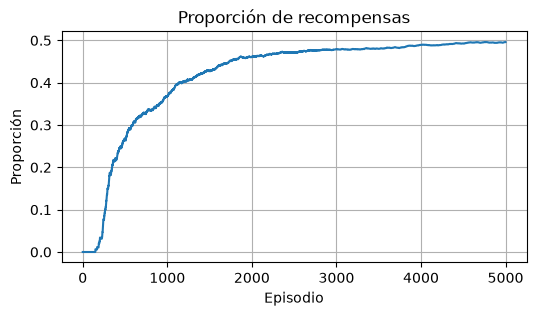

Máxima proporcion: 0.496


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

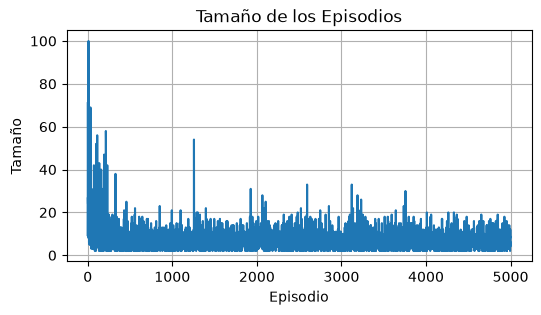

Máximo tamaño de episodio: 100


In [ ]:
#@title Evolución del tamaño por episodio

plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [11]:
# @title Política final 4x4
LEFT, DOWN, RIGHT, UP = 0,1,2,3
# Le pasamos la red entrenada 'Q_net' en vez de la matriz estática
pi, actions = pi_star_from_Q(env4, Q_net)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())

RuntimeError: mat1 and mat2 must have the same dtype, but got Long and Float

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



In [ ]:
# @title Aprendizaje 8x8
# Cambiado: de 'on_policy_all_visit' a 'train_dqn' y 'discount_factor' ajustado a 0.99 debido al tamaño del mapa
Q_net8, list_stats, list_episodes_length = train_dqn(env8, num_episodes=10000, epsilon=0.2, decay=True, discount_factor=0.95)

 10%|█         | 1004/10000 [01:29<08:40, 17.28it/s]

success: 0.001, epsilon: 0.999000999000999


 20%|██        | 2010/10000 [02:00<02:48, 47.30it/s]

success: 0.02, epsilon: 0.49975012493753124


 30%|███       | 3008/10000 [02:25<02:14, 52.17it/s]

...

 80%|████████  | 8006/10000 [04:49<00:55, 35.95it/s]

success: 0.4715, epsilon: 0.1249843769528809


 90%|█████████ | 9004/10000 [05:14<00:20, 48.85it/s]

success: 0.5066666666666667, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [05:39<00:00, 29.47it/s]


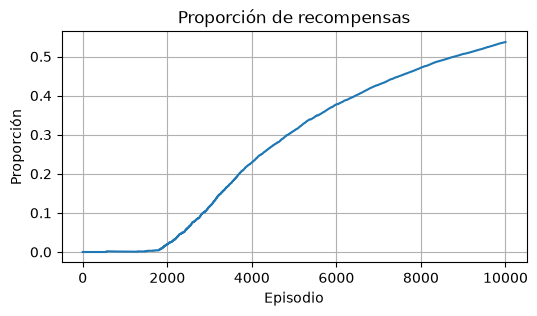

Máxima proporcion: 0.5371


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

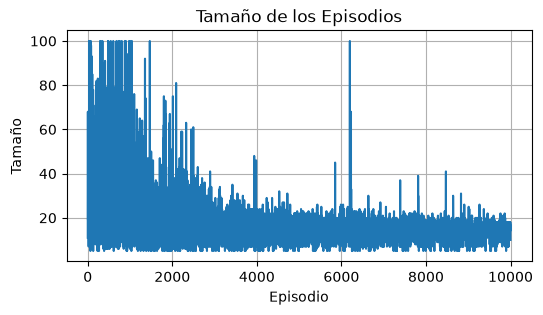

Máximo tamaño de episodio: 100


In [ ]:
#@title Evolución del tamaño por episodio

plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [ ]:
# @title Política final 8x8
LEFT, DOWN, RIGHT, UP = 0,1,2,3
# Le pasamos la red entrenada 'Q_net' en vez de la matriz estática
pi, actions = pi_star_from_Q(env8, Q_net8)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2,

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
